In [57]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [58]:
df = pd.read_csv('data/DoktorAvalanche_with_features_engineered_for_model.csv')

In [59]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'is_mistake', 'is_blunder', 'eval_unified', 'complexity_material_norm',
       'eval_volatility_norm', 'time_pressure_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure',
       'color_white', 'time_left_ratio_clipped', 'time_left_bin'],
      dtype='

In [60]:
df = df.drop(['time_left_bin', 'is_inaccuracy', 'is_mistake'], axis = 1)

In [61]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [62]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop('is_blunder', axis=1)
y = df['is_blunder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

In [63]:
X_train.shape

(20898, 42)

In [64]:
y_train.shape

(20898,)

In [65]:
y_train[y_train == 1].sum()

np.int64(661)

In [66]:
X_test.shape

(5225, 42)

In [67]:
y_test[y_test == 1].sum()

np.int64(165)

In [68]:
X_test.to_csv('model_data/X_test_blunder.csv', index=False)
y_test.to_csv('model_data/y_test_blunder.csv', index=False)

In [69]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure',
 'time_left_ratio_clipped']

In [70]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("q1:", Q1, "q3:", Q3, "IQR:", IQR, "lower_bound:", lower_bound, "upper_bound:", upper_bound)
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

for i in numeric_columns:
    print(i, ":", len(find_outliers_iqr(train_df[i])))

q1: 10.0 q3: 29.0 IQR: 19.0 lower_bound: -18.5 upper_bound: 57.5
move_number : 448
q1: 3.0 q3: 3.0 IQR: 0.0 lower_bound: 3.0 upper_bound: 3.0
increment_sec : 4503
q1: 103.71 q3: 272.51 IQR: 168.8 lower_bound: -149.49 upper_bound: 525.71
time_left_sec : 0
q1: 2.44 q3: 9.84 IQR: 7.4 lower_bound: -8.660000000000002 upper_bound: 20.94
time_spent_sec : 1675
q1: 0.38334999999999997 q3: 0.9382333333333336 IQR: 0.5548833333333336 lower_bound: -0.44897500000000046 upper_bound: 1.7705583333333341
time_left_ratio : 0
q1: 14.522013940527977 q3: 88.14382054176914 IQR: 73.62180660124116 lower_bound: -95.91069596133377 upper_bound: 198.57653044363087
eval_volatility : 2410
q1: 18.0 q3: 29.0 IQR: 11.0 lower_bound: 1.5 upper_bound: 45.5
pieces_remaining : 0
q1: 0.5625 q3: 0.90625 IQR: 0.34375 lower_bound: 0.046875 upper_bound: 1.421875
material_density : 0
q1: 3.0 q3: 7.0 IQR: 4.0 lower_bound: -3.0 upper_bound: 13.0
num_minor_pieces : 0
q1: 2.0 q3: 4.0 IQR: 2.0 lower_bound: -1.0 upper_bound: 7.0
num_ro

In [71]:
# Set option to display all rows
pd.set_option('display.max_rows', None)

In [72]:

train_df['move_number'].value_counts().sort_index(ascending = False)

move_number
91      1
89      1
88      2
87      2
86      2
85      3
84      3
83      4
82      3
81      4
80      5
79      4
78      3
77      7
76      7
75      7
74      8
73      8
72     12
71     13
70     13
69     15
68     19
67     21
66     25
65     20
64     23
63     26
62     28
61     34
60     28
59     49
58     48
57     55
56     60
55     64
54     69
53     79
52     84
51     93
50     92
49     97
48    108
47    114
46    123
45    124
44    137
43    149
42    153
41    158
40    175
39    193
38    190
37    215
36    220
35    230
34    246
33    288
32    306
31    334
30    348
29    384
28    405
27    413
26    444
25    464
24    502
23    509
22    525
21    532
20    584
19    601
18    625
17    630
16    661
15    643
14    653
13    661
12    664
11    690
10    671
9     662
8     667
7     670
6     661
5     687
4     664
3     674
Name: count, dtype: int64

In [73]:

train_df['increment_sec'].value_counts().sort_index(ascending = False)

increment_sec
5      228
4       48
3    16395
2     2772
0     1455
Name: count, dtype: int64

In [74]:
train_df['time_spent_sec'].value_counts().sort_index(ascending = False)

time_spent_sec
106.51      1
104.84      1
91.32       1
90.16       1
87.36       1
87.16       1
86.20       1
86.19       1
84.28       1
81.96       1
79.80       1
77.56       1
77.40       1
75.48       1
75.40       1
75.16       1
74.68       1
73.00       1
72.84       1
72.52       1
72.28       1
70.84       1
70.52       1
69.68       1
68.92       1
68.84       1
68.20       1
68.08       1
68.04       1
67.96       1
67.56       1
67.48       1
66.44       2
66.36       1
66.20       1
66.12       1
65.96       1
65.92       1
65.80       1
65.72       1
65.40       1
65.24       1
64.40       1
64.12       1
64.00       1
63.64       1
63.16       1
63.08       1
62.92       1
62.68       1
62.36       1
60.60       1
60.04       1
59.88       1
59.80       1
59.72       1
59.48       1
59.08       1
58.92       1
58.84       1
58.60       1
58.52       1
58.12       1
57.72       1
57.64       1
57.56       1
57.32       1
56.92       1
56.68       1
56.28       1
55.80

In [75]:
train_df['avg_time_spent_per_move'].value_counts().sort_index(ascending = False)

avg_time_spent_per_move
17.935000    13
16.581818     8
16.337500    13
15.926000    14
15.265909    17
15.113043    15
14.794348    16
14.330435    16
14.318333    18
14.120000    19
13.904667    11
13.875556    15
13.844375    13
13.835000    15
13.766957    17
13.526000    14
13.467727    16
13.275833    20
13.186667    24
13.001818    18
12.960000    14
12.957647    13
12.955862    18
12.950588    10
12.948276    17
12.820370    18
12.820000    19
12.788261    18
12.765769    20
12.758621    22
12.738400    16
12.640741    22
12.640000    19
12.605172    24
12.595500    16
12.471034    20
12.409677    20
12.397037    23
12.350476    11
12.251034    24
12.223214    23
12.210526    15
12.202414    21
12.188571    19
12.177500    23
12.082759    23
12.027308    16
12.027037    20
11.987600    12
11.971613    26
11.856842    10
11.823750    19
11.819259    17
11.767727    16
11.766364    16
11.754762    13
11.748148    17
11.724687    26
11.718710    24
11.707667    24
11.707586    24


In [76]:
train_df['eval_unified'].value_counts().sort_index(ascending = False)

eval_unified
 16955.400000     124
 16931.526923      42
 16907.653846      44
 16883.780769      44
 16859.907692      42
 16836.034615      40
 16812.161538      40
 16788.288462      25
 16764.415385      25
 16740.542308      17
 16716.669231      19
 16692.796154      21
 16668.923077       7
 16645.050000      12
 16621.176923       7
 16597.303846       2
 16573.430769       5
 16549.557692       2
 16525.684615       3
 16501.811538       4
 16477.938462       1
 16454.065385       1
 16430.192308       1
 16406.319231       1
 16382.446154       1
 16358.573077       2
 16334.700000       2
 16310.826923       2
 16286.953846       3
 16263.080769       1
 16239.207692       1
 16215.334615       1
 16143.715385       1
 16119.842308       1
 16072.096154       2
 16048.223077       1
 15785.619231       1
 15714.000000       1
 15414.000000       1
 9407.000000        1
 8514.000000        1
 8433.000000        1
 8255.000000        1
 7818.000000        1
 7575.000000       

In [77]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

Don't remove any outliers since these are all representative of data

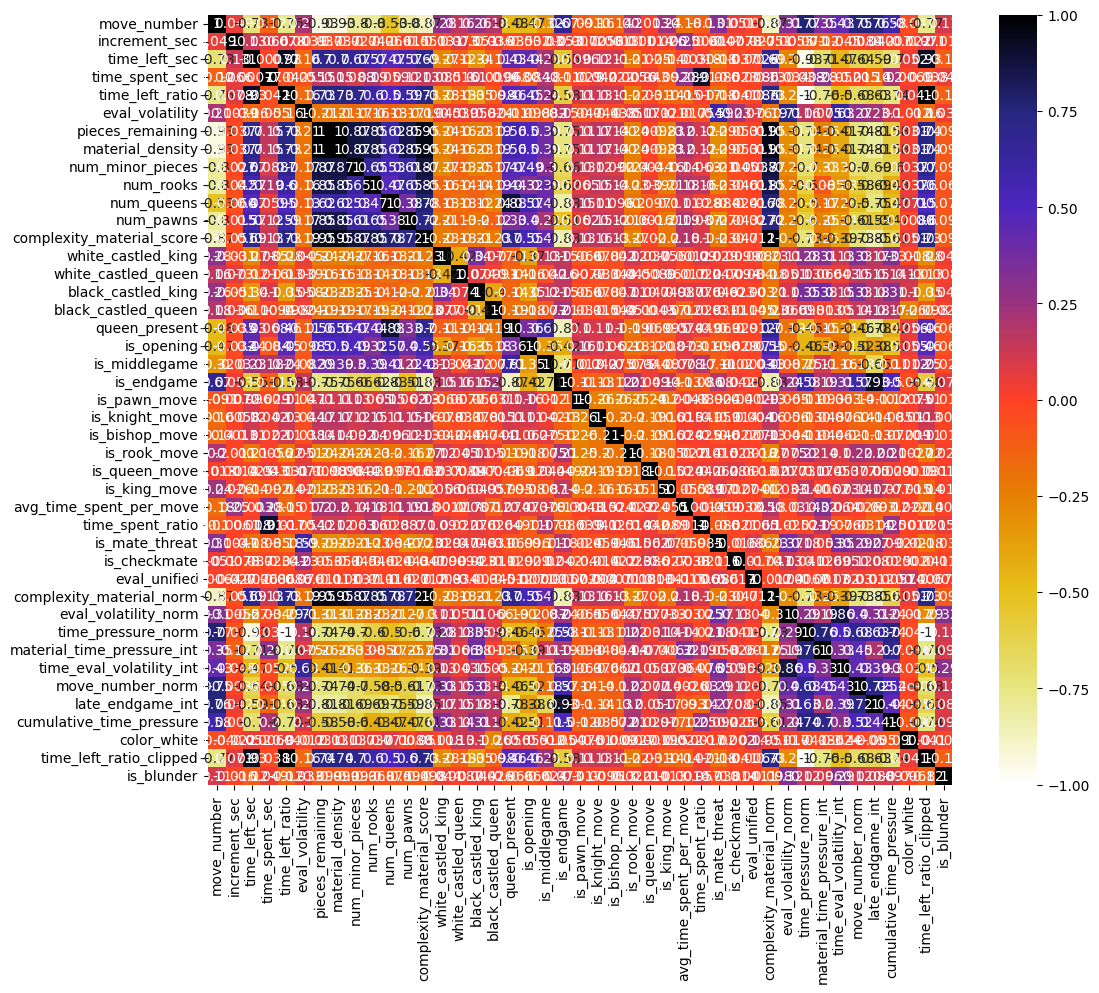

In [78]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = train_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [79]:
train_df.corr()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,...,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white,time_left_ratio_clipped,is_blunder
move_number,1.000000,0.048905,-0.725306,-0.124930,-0.762196,0.205334,-0.933893,-0.933893,-0.798179,-0.797376,...,0.312605,0.765960,0.345432,0.427599,0.753790,0.756266,0.581002,-0.040279,-0.765960,0.109278
increment_sec,0.048905,1.000000,0.131081,0.066121,0.078071,0.003917,-0.037206,-0.037206,-0.026960,-0.042417,...,-0.005543,-0.070551,-0.119216,-0.044754,-0.008439,0.041962,0.007022,-0.022372,0.070551,-0.016027
time_left_sec,-0.725306,0.131081,1.000000,-0.000769,0.930766,-0.156212,0.698140,0.698140,0.666068,0.571891,...,-0.274759,-0.934198,-0.710080,-0.468224,-0.638773,-0.594841,-0.704453,0.052104,0.934198,-0.116391
time_spent_sec,-0.124930,0.066121,-0.000769,1.000000,-0.041505,-0.054716,0.150694,0.150694,0.088272,0.185872,...,-0.033531,0.037525,0.280921,-0.051864,-0.014797,-0.144996,0.203167,0.006914,-0.037525,0.048985
time_left_ratio,-0.762196,0.078071,0.930766,-0.041505,1.000000,-0.159688,0.731764,0.731764,0.697335,0.599578,...,-0.285440,-0.999179,-0.758509,-0.500478,-0.679110,-0.629953,-0.740885,0.040426,0.999179,-0.121386
eval_volatility,0.205334,0.003917,-0.156212,-0.054716,-0.159688,1.000000,-0.206650,-0.206650,-0.169146,-0.163558,...,0.708884,0.161516,0.074756,0.632085,0.273692,0.226457,0.101726,-0.011996,-0.161516,0.032926
pieces_remaining,-0.933893,-0.037206,0.698140,0.150694,0.731764,-0.206650,1.000000,1.000000,0.865767,0.847193,...,-0.311385,-0.735145,-0.263921,-0.408767,-0.741656,-0.806478,-0.582676,0.031126,0.735145,-0.099064
material_density,-0.933893,-0.037206,0.698140,0.150694,0.731764,-0.206650,1.000000,1.000000,0.865767,0.847193,...,-0.311385,-0.735145,-0.263921,-0.408767,-0.741656,-0.806478,-0.582676,0.031126,0.735145,-0.099064
num_minor_pieces,-0.798179,-0.026960,0.666068,0.088272,0.697335,-0.169146,0.865767,0.865767,1.000000,0.654469,...,-0.277788,-0.699163,-0.329768,-0.358649,-0.701096,-0.694535,-0.601607,0.036843,0.699163,-0.092630
num_rooks,-0.797376,-0.042417,0.571891,0.185872,0.599578,-0.163558,0.847193,0.847193,0.654469,1.000000,...,-0.228022,-0.603127,-0.085297,-0.334848,-0.584432,-0.692750,-0.427557,0.036599,0.603127,-0.068036


In [80]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in the absolute coefficient value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [81]:
corr_features = correlation(train_df, 0.8)
len(set(corr_features))

15

In [82]:
corr_features

{'complexity_material_norm',
 'complexity_material_score',
 'is_endgame',
 'late_endgame_int',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_rooks',
 'pieces_remaining',
 'queen_present',
 'time_eval_volatility_int',
 'time_left_ratio',
 'time_left_ratio_clipped',
 'time_pressure_norm',
 'time_spent_ratio'}

Determine columns to drop

In [83]:
X_train = X_train.drop([
'move_number',
'eval_volatility',
 'complexity_material_score',
 'time_left_ratio',
 'is_opening',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_queens',
 'num_rooks',
 'pieces_remaining'], axis=1) 

In [84]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'eval_unified',
       'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [85]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train, random_state=42)
mutual_info

array([0.        , 0.00882974, 0.00225982, 0.00403146, 0.00039871,
       0.00315116, 0.00010855, 0.00439993, 0.00014218, 0.00667482,
       0.00147297, 0.        , 0.0011913 , 0.00039702, 0.00034428,
       0.        , 0.00352503, 0.00120188, 0.00305117, 0.        ,
       0.01678714, 0.00617383, 0.05842564, 0.00883585, 0.00540288,
       0.03930444, 0.00848129, 0.00343203, 0.00890421, 0.00447172,
       0.00943879])

In [86]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

eval_volatility_norm          0.058426
time_eval_volatility_int      0.039304
eval_unified                  0.016787
time_left_ratio_clipped       0.009439
cumulative_time_pressure      0.008904
time_pressure_norm            0.008836
time_left_sec                 0.008830
move_number_norm              0.008481
is_endgame                    0.006675
complexity_material_norm      0.006174
material_time_pressure_int    0.005403
color_white                   0.004472
queen_present                 0.004400
white_castled_king            0.004031
avg_time_spent_per_move       0.003525
late_endgame_int              0.003432
black_castled_king            0.003151
is_mate_threat                0.003051
time_spent_sec                0.002260
is_pawn_move                  0.001473
time_spent_ratio              0.001202
is_bishop_move                0.001191
white_castled_queen           0.000399
is_rook_move                  0.000397
is_queen_move                 0.000344
is_middlegame            

In [87]:

# Get column names where mutual info is less than 0
low_mi_columns = mutual_info[mutual_info <= 0].index.tolist()

print(low_mi_columns)

['increment_sec', 'is_knight_move', 'is_king_move', 'is_checkmate']


In [88]:
X_train = X_train.drop(low_mi_columns, axis=1)

In [89]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [90]:
X_train.shape

(20898, 27)

In [91]:
X_test.shape

(5225, 27)

In [92]:
train_df = pd.concat([X_train, y_train], axis=1)

After splitting — run VIF (Variance Inflation Factor) on the training set only.

* VIF measures how much the variance of a coefficient is inflated due to multicollinearity with other features.

* Formula: VIF_i = 1 / (1 - Rscore_i)
* where Rscore_i is the coefficient of determination from regressing feature i on all other features.

* Interpretation:
 - VIF = 1: No correlation with other features
 - VIF = 5: Rscore = 0.80 (feature is 80% predictable from others)
 - VIF = 10: Rscore = 0.90 (feature is 90% predictable from others)

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF ANALYSIS

def calculate_vif(df, features):
    vif_data = []
    
    # Remove rows with any NaN in the features
    df_clean = df[features].dropna()
    
    if len(df_clean) < 2:
        print("Not enough data for VIF calculation")
        return pd.DataFrame()
    
    print(f"\nCalculating VIF for {len(features)} features")
    print(f"Using {len(df_clean)} complete cases")
    
    for i, feature in enumerate(features):
        try:
            vif = variance_inflation_factor(df_clean.values, i)
            vif_data.append({
                'Feature': feature,
                'VIF': vif,
                'Status': 'SEVERE (>10)' if vif > 10 else 'MODERATE (5-10)' if vif > 5 else 'OK (<5)'
            })
        except Exception as e:
            vif_data.append({
                'Feature': feature,
                'VIF': np.nan,
                'Status': 'ERROR'
            })
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Calculate VIF for all continuous features
print("\n VIF for All Features")
vif_all = calculate_vif(X_train, X_train.columns)

if len(vif_all) > 0:
    print("\n", vif_all.to_string(index=False))
    
    # Identify problematic features
    severe_vif = vif_all[vif_all['VIF'] > 10]
    moderate_vif = vif_all[(vif_all['VIF'] >= 5) & (vif_all['VIF'] <= 10)]
    
    print(f"\n VIF Summary:")
    print(f"SEVERE (VIF > 10): {len(severe_vif)} features")
    print(f"MODERATE (VIF 5-10): {len(moderate_vif)} features")
    print(f"OK (VIF < 5): {len(vif_all) - len(severe_vif) - len(moderate_vif)} features")
    
else:
    print("Could not calculate VIF")



 VIF for All Features

Calculating VIF for 27 features
Using 20898 complete cases

                    Feature        VIF          Status
   time_left_ratio_clipped 170.972129    SEVERE (>10)
        time_pressure_norm  50.775545    SEVERE (>10)
                is_endgame  20.804386    SEVERE (>10)
          late_endgame_int  16.766248    SEVERE (>10)
  complexity_material_norm  14.806725    SEVERE (>10)
material_time_pressure_int  10.862273    SEVERE (>10)
            time_spent_sec  10.805531    SEVERE (>10)
          time_spent_ratio  10.269017    SEVERE (>10)
             time_left_sec   9.734991 MODERATE (5-10)
  time_eval_volatility_int   6.710181 MODERATE (5-10)
      eval_volatility_norm   5.820418 MODERATE (5-10)
  cumulative_time_pressure   5.496105 MODERATE (5-10)
          move_number_norm   5.065068 MODERATE (5-10)
             queen_present   4.435364         OK (<5)
             is_middlegame   3.736528         OK (<5)
   avg_time_spent_per_move   2.637667         OK (<

In [94]:
# remove the columns
cols_to_drop = ['is_endgame', 'time_spent_sec']

In [95]:
X_train = X_train.drop(cols_to_drop, axis=1)

In [96]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [97]:
X_train.shape

(20898, 25)

In [98]:
X_test.shape

(5225, 25)

In [99]:
train_df = pd.concat([X_train, y_train], axis=1)

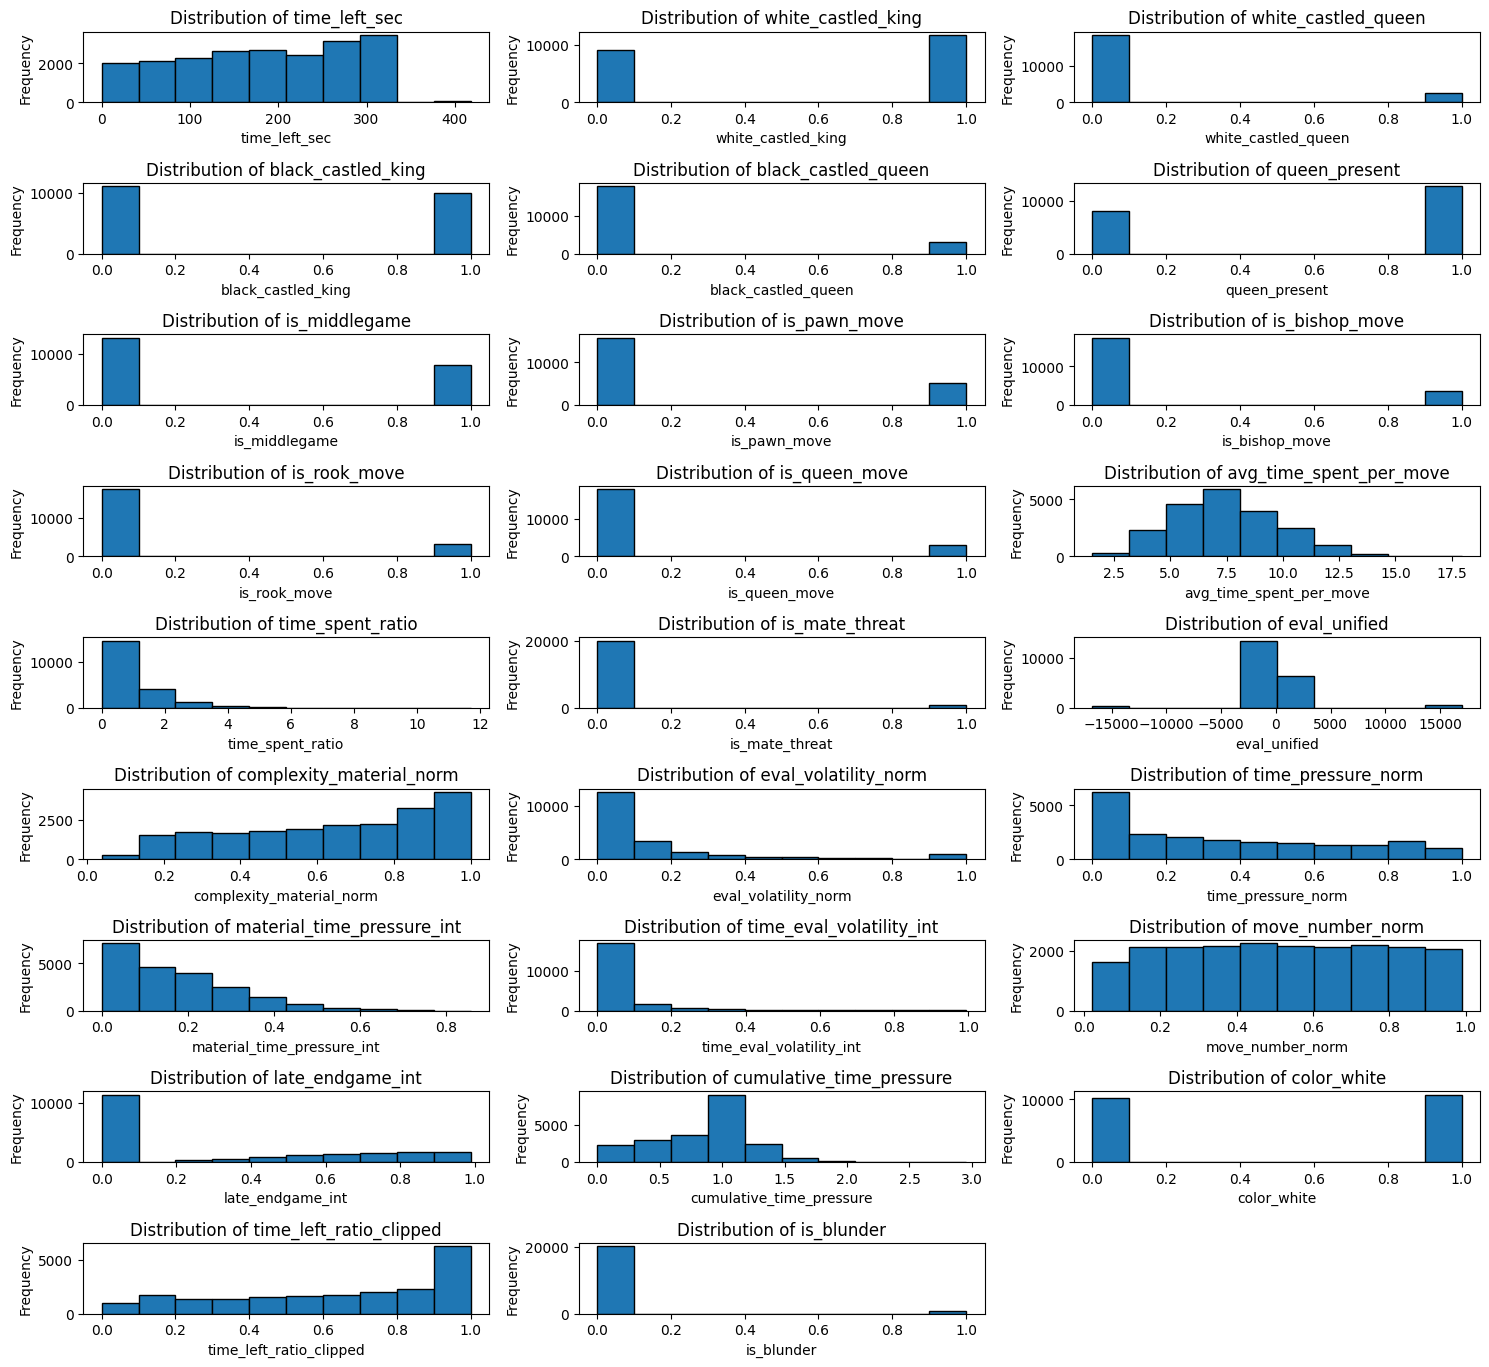

In [100]:
columns_df = train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [101]:
log_features = [
    'time_spent_ratio', 
]

for col in log_features:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

In [102]:
# eval_unified
for col in ['eval_unified']:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)

In [103]:
scale_only_features = [
    # Roughly uniform — no skew to fix
    'time_left_sec',              # uniform 
    'complexity_material_norm',   # roughly uniform increasing
    'move_number_norm',           # roughly uniform

    # Bell-shaped / near-normal — StandardScaler is appropriate as-is
    'avg_time_spent_per_move',    # bell-shaped
    'cumulative_time_pressure',   # bell-shaped

    # Already 0-1, right-skewed or zero-inflated
    'eval_volatility_norm',
    'time_pressure_norm',
    'material_time_pressure_int',
    'time_eval_volatility_int',
    'late_endgame_int',
    'time_left_ratio_clipped',    # left-skewed but bounded
]

In [104]:
from sklearn.preprocessing import StandardScaler
import numpy as np

log_cols = ['time_spent_ratio']
for col in log_cols:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

lo = X_train['eval_unified'].quantile(0.01)
hi = X_train['eval_unified'].quantile(0.99)
X_train['eval_unified'] = X_train['eval_unified'].clip(lo, hi)
X_test['eval_unified']  = X_test['eval_unified'].clip(lo, hi)

scale_cols = log_cols + ['eval_unified'] + scale_only_features

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [105]:
scaled_train_df = pd.concat([X_train, y_train], axis=1)

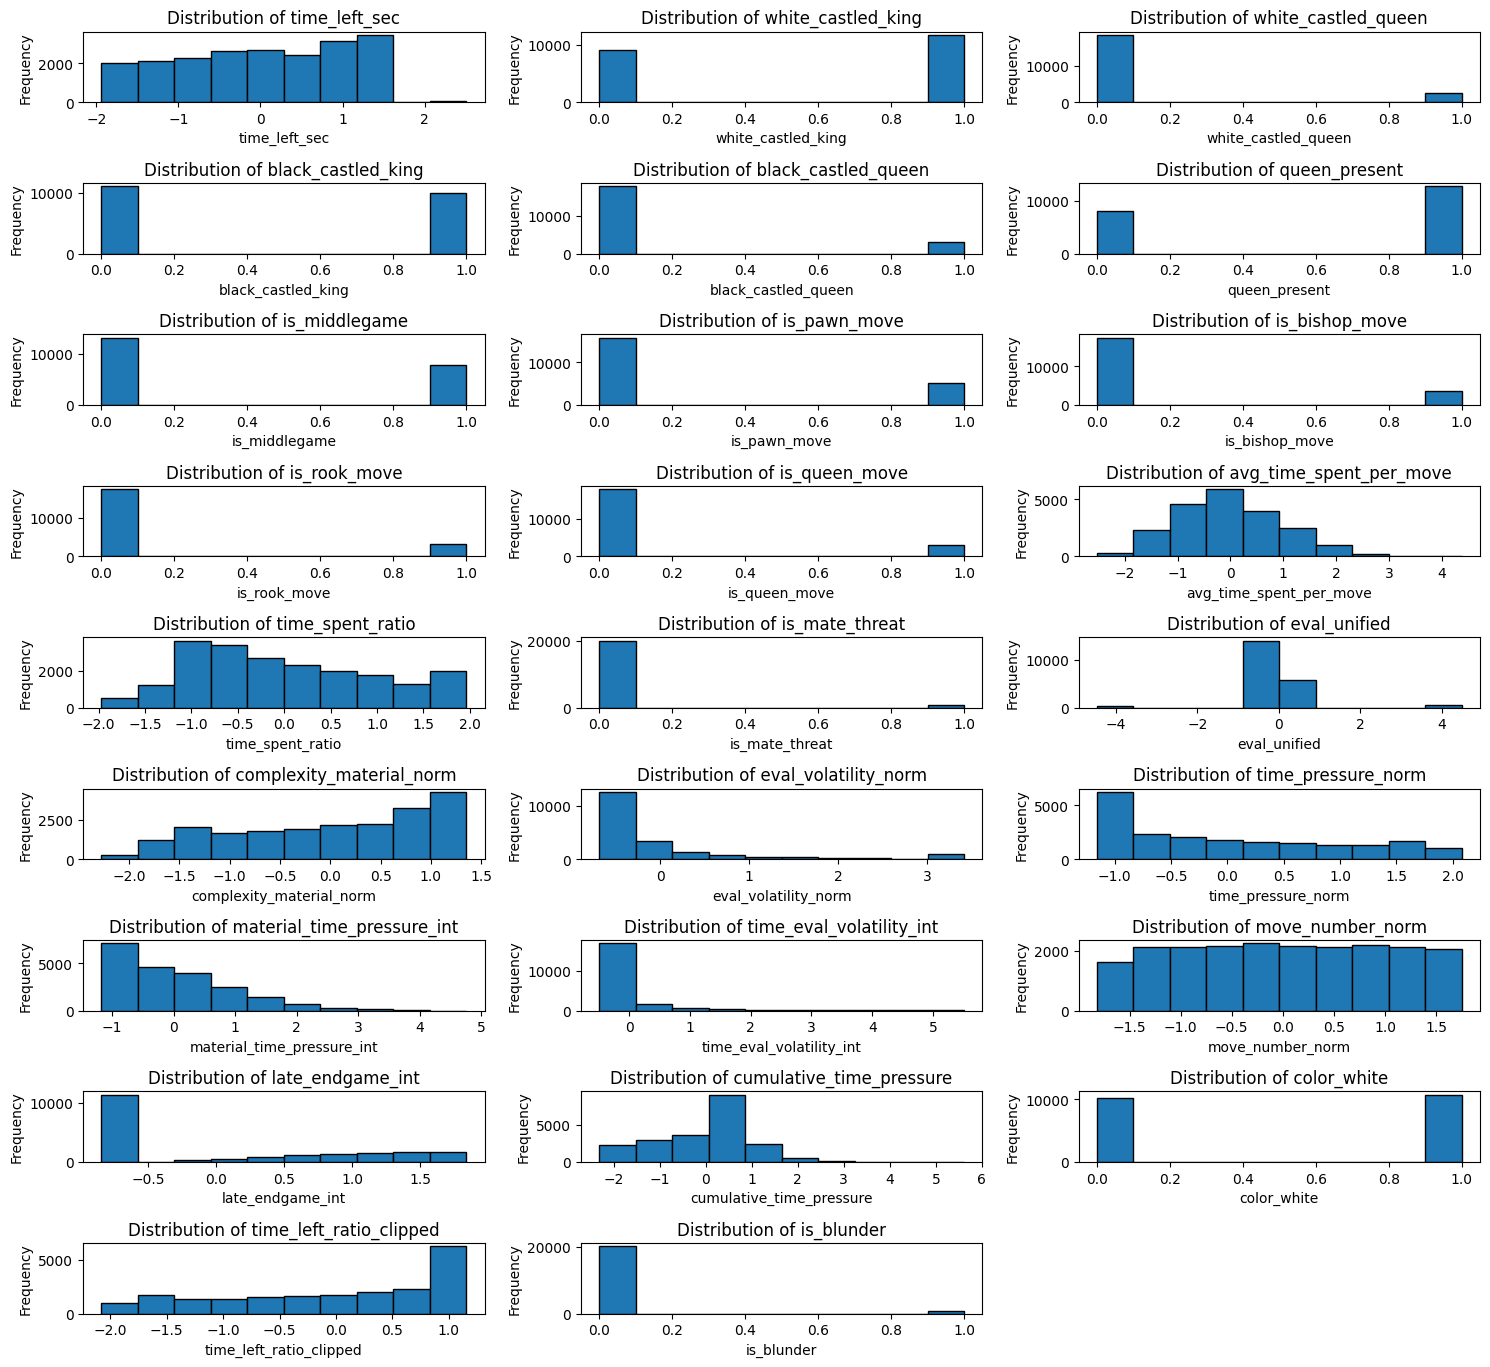

In [106]:
columns_df = scaled_train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(scaled_train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [107]:
X_train.to_csv('model_data/scaled_blunder_blitz_X_train.csv', index=False)
X_test.to_csv('model_data/scaled_blunder_blitz_X_test.csv', index=False)

In [108]:
y_train.to_csv('model_data/blunder_blitz_y_train.csv', index=False)
y_test.to_csv('model_data/blunder_blitz_y_test.csv', index=False)